<a href="https://colab.research.google.com/github/devdatta1429/BDA_Assignments/blob/main/PML/Day_25_13_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
from google.colab import drive
drive.mount('/content/drive')


import numpy as np
import pandas as pd

import os
os.chdir('/content/drive/MyDrive/CDAC/')

import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

from numpy import random
from collections import Counter

from numpy.linalg import inv
from numpy.linalg import eig

import matplotlib
from matplotlib import pyplot as plt

import seaborn as sns

import pylab
from pylab import legend
from pylab import plot, show, title, xlabel, ylabel

import scipy
from scipy import stats
from scipy.stats import binom,poisson,norm,t,expon,f
from sklearn.model_selection import train_test_split

import statsmodels
from statsmodels import stats
from statsmodels.stats import weightstats as ssw

import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from scipy.stats import chisquare
from scipy.stats import chi2_contingency

from statsmodels.stats import rates
from statsmodels.stats.rates import test_poisson
from statsmodels.stats.rates import test_poisson_2indep

from scipy.stats import chi2

from scipy.stats import f
from sklearn.metrics import mean_squared_error

from sklearn.metrics import roc_auc_score

#========================================================================

import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
from statsmodels.discrete.discrete_model import MNLogit

import sklearn
from sklearn.model_selection import train_test_split



import pandas as pd
import sklearn
from sklearn import linear_model
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler

from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler

# from category_encoders import BinaryEncoder
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier


from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error
from math import sqrt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Time Series Components

## Definition
A time series is a sequence of observations recorded over time at regular intervals.

Examples:
- Daily stock prices
- Monthly sales
- Annual population data
- Hourly temperature readings

---

# Components of Time Series

A time series consists of four major components:

1. Trend (T)
2. Seasonal Variation (S)
3. Cyclical Variation (C)
4. Random Variation (R)

Mathematical Representation:

Y(t) = T + S + C + R

where:
- Y(t) = Observed value
- T = Trend
- S = Seasonal component
- C = Cyclical component
- R = Random component

---

## 1. Trend (T)

### Definition
Trend represents the long-term movement of data over time.

### Types
- Upward Trend
- Downward Trend
- No Trend

### Example

Year | Sales
---- | -----
2020 | 100
2021 | 120
2022 | 140
2023 | 170
2024 | 200

Observation:
Sales are increasing over time, indicating an upward trend.

### Characteristics
- Long-term direction
- Smooth movement
- Does not repeat periodically

---

## 2. Seasonal Variation (S)

### Definition
Seasonal variation refers to patterns that repeat at fixed intervals.

### Examples
- Ice cream sales increase during summer.
- Retail sales increase during festival seasons.
- Electricity usage increases during winter or summer.

### Characteristics
- Fixed and predictable pattern
- Repeats every day, week, month, quarter, or year

### Example

Month | Sales
----- | -----
Jan | 100
Feb | 110
Mar | 120
Apr | 150
May | 180
Jun | 200

The same pattern repeats every year.

---

## 3. Cyclical Variation (C)

### Definition
Cyclical variation represents fluctuations occurring over long periods due to economic or business cycles.

### Stages
1. Expansion
2. Peak
3. Recession
4. Recovery

### Examples
- Economic boom and recession
- Housing market cycles
- Business growth cycles

### Characteristics
- No fixed time interval
- Lasts several years
- Difficult to predict exactly

### Difference from Seasonality

Seasonal Variation:
- Fixed interval
- Short-term repetition

Cyclical Variation:
- No fixed interval
- Long-term fluctuations

---

## 4. Random Variation (R)

### Definition
Random variation consists of irregular and unpredictable changes.

### Causes
- Natural disasters
- Pandemics
- Strikes
- Accidents
- Sudden policy changes

### Characteristics
- Unpredictable
- Non-repeating
- Cannot be modeled easily

### Example

Expected Sales = 150

Actual Sales after disaster = 90

The sudden drop is due to random variation.

---

# Summary Table

Component | Meaning | Repeats? | Example
--------- | ------- | -------- | -------
Trend | Long-term movement | No | Sales growth
Seasonal | Fixed periodic pattern | Yes | Festival sales
Cyclical | Economic/business cycle | No fixed interval | Recession
Random | Unpredictable fluctuation | No | Pandemic impact

---

# Key Points

- Trend shows overall direction.
- Seasonal variation repeats at fixed intervals.
- Cyclical variation occurs over long periods without a fixed pattern.
- Random variation is irregular and unpredictable.
- Understanding these components helps in forecasting future values.

# Forecast Error Metrics

Forecast error metrics are used to evaluate how well a prediction model performs by comparing actual values with predicted values.

---

## Sample Data

| Actual | Predicted | Error | Absolute Error | Absolute Percentage Error (%) | Squared Error |
|----------|----------|----------|----------|----------|----------|
| 7 | 9 | -2 | 2 | 28.6 | 4 |
| 6 | 7 | -1 | 1 | 16.7 | 1 |
| 8 | 6 | 2 | 2 | 25.0 | 4 |
| 4 | 9 | -5 | 5 | 125.0 | 25 |
| 6 | 8 | -2 | 2 | 33.3 | 4 |
| 7 | 5 | 2 | 2 | 28.6 | 4 |
| 8 | 7 | 1 | 1 | 12.5 | 1 |
| 7 | 6 | 1 | 1 | 14.3 | 1 |
| 9 | 9 | 0 | 0 | 0.0 | 0 |
| 6 | 8 | -2 | 2 | 33.3 | 4 |

---

# 1. Mean Error (ME)

### Definition
Mean Error measures the average forecasting error and indicates whether predictions are generally overestimating or underestimating actual values.

### Formula

\[
ME = \frac{\sum (Actual - Predicted)}{n}
\]

### Calculation

\[
ME = \frac{-6}{10}
\]

\[
ME = -0.6
\]

### Interpretation
- ME > 0 : Model tends to underestimate.
- ME < 0 : Model tends to overestimate.
- ME = 0 : No overall bias.

**Result:** ME = -0.6

---

# 2. Mean Absolute Error (MAE)

### Definition
MAE measures the average magnitude of errors without considering their direction.

### Formula

\[
MAE = \frac{\sum |Actual - Predicted|}{n}
\]

### Calculation

\[
MAE = \frac{18}{10}
\]

\[
MAE = 1.8
\]

### Interpretation
Lower MAE indicates better forecasting accuracy.

**Result:** MAE = 1.8

---

# 3. Mean Absolute Percentage Error (MAPE)

### Definition
MAPE expresses forecasting error as a percentage of the actual value.

### Formula

\[
MAPE = \frac{100}{n}
\sum
\left|
\frac{Actual - Predicted}{Actual}
\right|
\]

### Calculation

Average Percentage Error:

\[
\frac{28.6+16.7+25+125+33.3+28.6+12.5+14.3+0+33.3}{10}
\]

\[
MAPE = 31.73\%
\]

### Interpretation
- Lower MAPE indicates better predictions.
- Easy to understand because it is expressed in percentage form.

**Result:** MAPE = 31.73%

---

# 4. Mean Squared Error (MSE)

### Definition
MSE measures the average of squared forecasting errors.

### Formula

\[
MSE = \frac{\sum (Actual - Predicted)^2}{n}
\]

### Calculation

Sum of Squared Errors:

\[
4+1+4+25+4+4+1+1+0+4 = 48
\]

\[
MSE = \frac{48}{10}
\]

\[
MSE = 4.8
\]

### Interpretation
- Larger errors receive higher penalties because errors are squared.
- Widely used in machine learning and forecasting models.

**Result:** MSE = 4.8

---

# Summary Table

| Metric | Formula | Result |
|----------|----------|----------|
| Mean Error (ME) | Σ Error / n | -0.6 |
| Mean Absolute Error (MAE) | Σ Absolute Error / n | 1.8 |
| Mean Absolute Percentage Error (MAPE) | Σ Percentage Error / n | 31.73% |
| Mean Squared Error (MSE) | Σ Squared Error / n | 4.8 |

---

# Key Points

- **ME** measures forecast bias.
- **MAE** measures average error magnitude.
- **MAPE** measures percentage forecasting error.
- **MSE** penalizes large errors more heavily.
- Lower MAE, MAPE, and MSE indicate better model performance.

In [35]:
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error
from math import sqrt

In [36]:
df = pd.read_excel('CDAC_DataBook.xlsx', sheet_name='birth')
df.head(2)

,BirthRate
0,26.663
1,23.598


<Axes: >

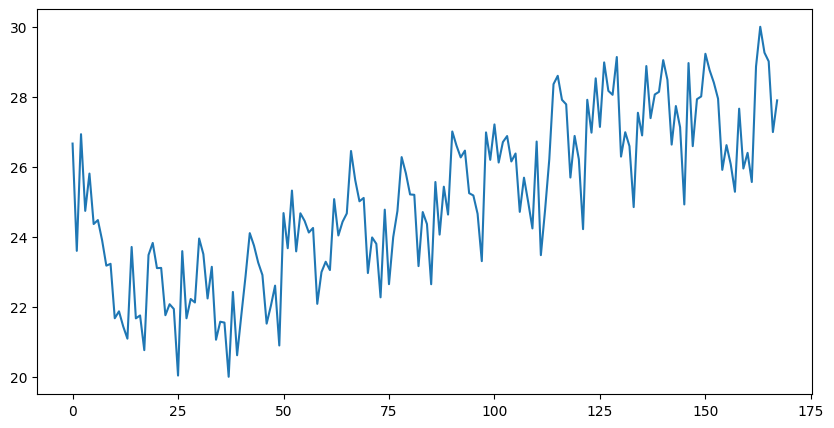

In [37]:
df.BirthRate.plot(figsize=(10,5)) # plotting the time series

In [38]:
from statsmodels.tsa.seasonal import seasonal_decompose as ssd

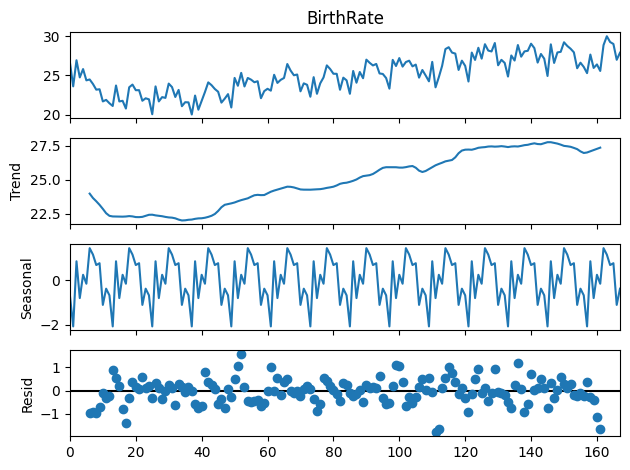

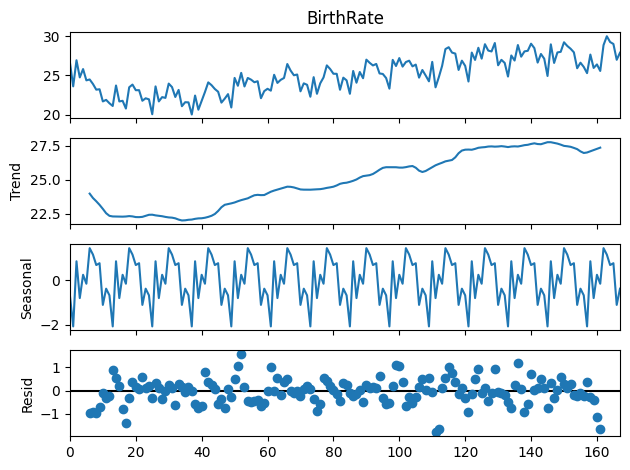

In [39]:
ssd(df.BirthRate, period=12).plot()

In [40]:
df_train = df.iloc[:144]  # training dataset for training the models
df_test = df.iloc[144:]    # test dataset for calculating rmse based on the predictions

In [41]:
df_train.shape

(144, 1)

In [42]:
df_test.shape

(24, 1)

## 🔰Naive Method🔰

In [43]:
df_test['naive'] = df_train.BirthRate.iloc[-1]
# np.float64(27.735)

In [45]:
sqrt(mean_squared_error(df_test.BirthRate, df_test.naive))

1.4277309211939526

#
#
#


## 🔰Simple Average Method🔰

In [63]:
df_test['SimpAvg'] = df_train.BirthRate.mean()   # np.float64(24.656833333333335)
sqrt(mean_squared_error(df_test.BirthRate, df_test.SimpAvg))


3.147657647627305

In [57]:
df_train.BirthRate.iloc[-12:]

#      BirthRate
# 132	26.589
# 133	24.848
# 134	27.543
# 135	26.896
# 136	28.878
# 137	27.390
# 138	28.065
# 139	28.141
# 140	29.048
# 141	28.484
# 142	26.634
# 143	27.735


df_train.BirthRate.iloc[-12:].mean()
# np.float64(27.52091666666667)

np.float64(27.52091666666667)

### 🔶12 Months Moving Average🔶

In [60]:
df_test['12Mths_Moving_Avg'] = df_train.BirthRate.iloc[-12:].mean()  # np.float64(27.52091666666667)
sqrt(mean_squared_error(df_test.BirthRate, df_test['12Mths_Moving_Avg']))

1.4044810849760687

### 🔶24 Months Moving Average🔶

In [61]:
df_test['24Mths_Moving_Avg'] = df_train.BirthRate.iloc[-24:].mean()
sqrt(mean_squared_error(df_test.BirthRate, df_test['24Mths_Moving_Avg']))

1.4038687245726835